In [1]:
import pandas as pd
import numpy as np
import shap
from xgboost import XGBRegressor, plot_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# scikit-optimize imports for Bayesian tuning
from skopt import BayesSearchCV
from skopt.space import Real, Integer
from sklearn.linear_model import LinearRegression

In [3]:
# Load data
df = pd.read_csv("/Users/Banjo/OneDrive/Desktop/MIDS/Summer 2025/DataSci 207/Final Project/w207FinalProject/data/processed/processed_plays.csv")

# simply display the Index of column names
print(df.columns)

# or get a plain Python list
columns_list = df.columns.tolist()
print(columns_list)

# If you also want dtypes and non‑null counts:
print(df.info())



Index(['down', 'yardsToGo', 'absoluteYardlineNumber', 'quarter', 'playAction',
       'qbSneak', 'pff_runPassOption', 'yardsGained',
       'secondsRemainingInQuarter', 'offFormation_EMPTY',
       'offFormation_I_FORM', 'offFormation_JUMBO', 'offFormation_PISTOL',
       'offFormation_SHOTGUN', 'offFormation_SINGLEBACK',
       'offFormation_WILDCAT', 'leftReceivers', 'rightReceivers',
       'dropbackType_DESIGNED_ROLLOUT_LEFT',
       'dropbackType_DESIGNED_ROLLOUT_RIGHT', 'dropbackType_DESIGNED_RUN',
       'dropbackType_QB_SNEAK', 'dropbackType_SCRAMBLE',
       'dropbackType_SCRAMBLE_ROLLOUT_LEFT',
       'dropbackType_SCRAMBLE_ROLLOUT_RIGHT', 'dropbackType_TRADITIONAL',
       'dropbackType_UNKNOWN', 'rushLocation_INSIDE_LEFT',
       'rushLocation_INSIDE_RIGHT', 'rushLocation_NONE',
       'rushLocation_OUTSIDE_LEFT', 'rushLocation_OUTSIDE_RIGHT',
       'rushConcept_COUNTER', 'rushConcept_DRAW', 'rushConcept_FB_RUN',
       'rushConcept_INSIDE_ZONE', 'rushConcept_MAN', 'rushCo

In [17]:

dfraw = pd.read_csv("/Users/Banjo/OneDrive/Desktop/MIDS/Summer 2025/DataSci 207/Final Project/w207FinalProject/data/raw/plays.csv")

# print(dfraw.columns)

# # or get a plain Python list
# columns_list = dfraw.columns.tolist()
# print(columns_list)

# # If you also want dtypes and non‑null counts:
# print(dfraw.info())

combo_counts = (
    dfraw
    .groupby(['offenseFormation', 'pff_passCoverage', 'pff_manZone'])
    .size()
    .reset_index(name='count')
)

# 2. Print how many unique combos you have
print(f"Total unique offenseFormation : pff_passCoverage : pff_manZone combos: {combo_counts.shape[0]}")

# 3. See the most frequent combos
combo_counts_sorted = combo_counts.sort_values('count', ascending=False)



combo_counts_sorted.to_csv('/Users/Banjo/OneDrive/Desktop/MIDS/Summer 2025/DataSci 207/Final Project/w207FinalProject/data/processed/offense_passcov_zone_combos.csv')

Total unique offenseFormation : pff_passCoverage : pff_manZone combos: 94


In [5]:
# Define features and target
#Train/Validation/Test split (60/20/20)
train_val, test = train_test_split(df, test_size=0.20, random_state=42)
train, val      = train_test_split(train_val, test_size=0.20, random_state=42)

X_train, y_train = train.drop('yardsGained', axis=1), train['yardsGained']
X_val,   y_val   = val.drop('yardsGained', axis=1),   val['yardsGained']
X_test,  y_test  = test.drop('yardsGained', axis=1),  test['yardsGained']


In [5]:
linreg = LinearRegression()
linreg.fit(X_train, y_train)

# Predict on training set and report R²
train_pred = linreg.predict(X_train)
r2_train = r2_score(y_train, train_pred)
print(f"Linear Regression R² on train data: {r2_train:.3f}")

# Define a loss function returning RMSE and MAE
def compute_loss(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return rmse, mae

# Evaluate baseline on train and validation sets
train_rmse, train_mae = compute_loss(y_train, train_pred)
val_pred              = linreg.predict(X_val)
val_rmse, val_mae     = compute_loss(y_val, val_pred)

print(f"Baseline losses on train data RMSE: {train_rmse:.3f}  MAE: {train_mae:.3f}")
print(f"Baseline losses on validation data RMSE: {val_rmse:.3f}  MAE: {val_mae:.3f}")

Linear Regression R² on train data: 0.032
Baseline losses on train data RMSE: 8.744  MAE: 5.823
Baseline losses on validation data RMSE: 8.173  MAE: 5.569


In [6]:
model = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_estimators=100,            
    learning_rate=0.0001,
    early_stopping_rounds=10,     
    eval_metric='rmse'            
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=10,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.0001, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [7]:
def evaluate(name, actual, pred):
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae  = mean_absolute_error(actual, pred)
    r2 = r2_score(actual, pred)
    print(f"{name} → RMSE: {rmse:.3f}, MAE: {mae:.3f}, R²: {r2:.3f}")

evaluate('Train', y_train, model.predict(X_train))
evaluate('Validation', y_val,   model.predict(X_val))
evaluate('Test', y_test,  model.predict(X_test))


Train → RMSE: 8.882, MAE: 5.993, R²: 0.001
Validation → RMSE: 8.280, MAE: 5.712, R²: 0.000
Test → RMSE: 9.188, MAE: 6.102, R²: 0.001


<Figure size 1000x800 with 0 Axes>

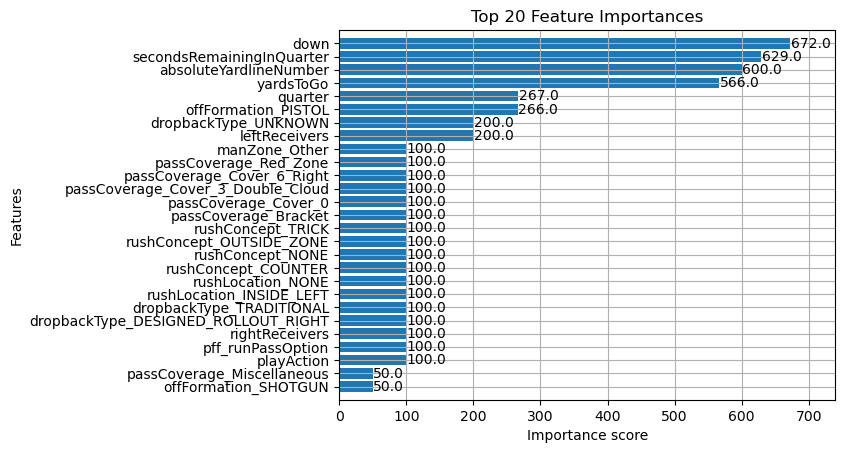

In [8]:
# Feature importance (top 20)
plt.figure(figsize=(10,8))
plot_importance(model, max_num_features=66, height=0.8)
plt.title('Top 20 Feature Importances')
plt.show()

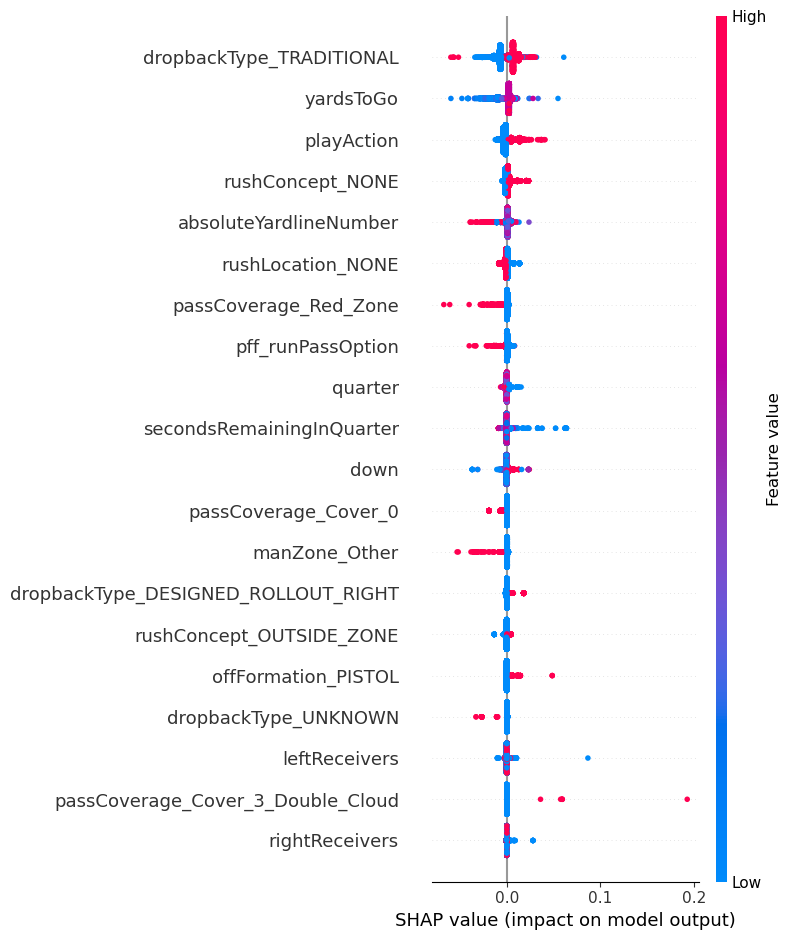

In [9]:
# SHAP summary plot
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)
shap.summary_plot(shap_values, X_train, show=False)
plt.tight_layout()
plt.show()

In [10]:
# Hyperparameter tuning via scikit-optimize’s BayesSearchCV
search_spaces = {
    'max_depth':        Integer(3, 10),
    'learning_rate':    Real(0.01, 0.3, prior='log-uniform'),
    'subsample':        Real(0.5, 1.0),
    'colsample_bytree': Real(0.5, 1.0),
    'n_estimators':     Integer(50, 300)
}

bayes_cv = BayesSearchCV(
    estimator=XGBRegressor(objective='reg:squarederror', random_state=42),
    search_spaces=search_spaces,
    n_iter=25,
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

bayes_cv.fit(X_train, y_train)
best_params = bayes_cv.best_params_
print("Best hyperparameters found:")
print(best_params)


KeyboardInterrupt: 

In [ ]:
final_model = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    **best_params
)

final_X = pd.concat([X_train, X_val], axis=0)
final_y = pd.concat([y_train, y_val], axis=0)

final_model.fit(final_X, final_y)


# Final evaluation on held-out test set
evaluate('Final Test', y_test, final_model.predict(X_test))

Final Test → RMSE: 9.041, MAE: 5.862, R²: 0.032


Root mean squared error: 9.1296
R squared score:          0.0132


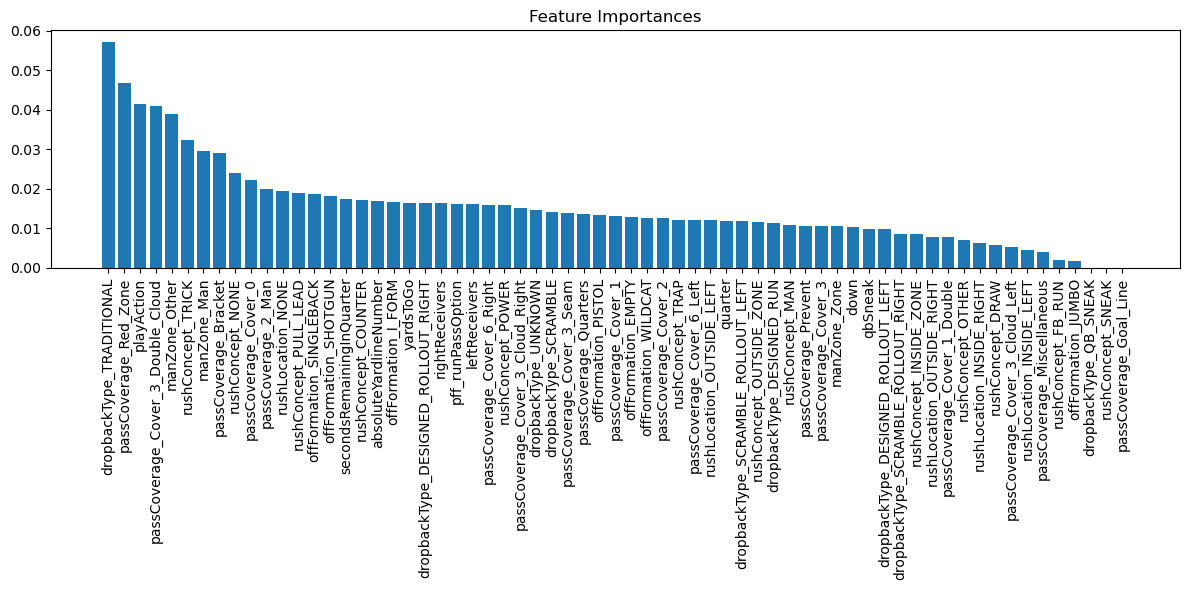

In [ ]:
#learned embedding layer